In [2]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Cars_Datasets_2025.csv", encoding="latin1")
print(df.head())

  Company Names     Cars Names      Engines CC/Battery Capacity HorsePower  \
0       FERRARI  SF90 STRADALE           V8             3990 cc     963 hp   
1   ROLLS ROYCE        PHANTOM          V12             6749 cc     563 hp   
2          Ford            KA+  1.2L Petrol            1,200 cc   70-85 hp   
3      MERCEDES        GT 63 S           V8            3,982 cc     630 hp   
4          AUDI     AUDI R8 Gt          V10            5,204 cc     602 hp   

  Total Speed Performance(0 - 100 )KM/H      Cars Prices       Fuel Types  \
0    340 km/h                   2.5 sec      $1,100,000   plug in hyrbrid   
1    250 km/h                   5.3 sec        $460,000            Petrol   
2    165 km/h                  10.5 sec  $12,000-$15,000           Petrol   
3    250 km/h                   3.2 sec        $161,000            Petrol   
4    320 km/h                   3.6 sec        $253,290            Petrol   

  Seats        Torque  
0     2        800 Nm  
1     5        900 N

In [18]:
# --- Encode categorical/text features ---
le_dict = {}
for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # encode everything as int
    le_dict[col] = le

In [19]:
# --- Features & target (Fuel Types as target) ---
X = df.drop(columns=["Fuel Types"]).values
y = df["Fuel Types"].values


In [20]:
# --- Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [21]:
# --- k-NN implementation ---
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [np.sqrt(np.sum((x - x_train) ** 2)) for x_train in self.X_train]
        k_idx = np.argsort(distances)[:self.k]
        k_neighbor_labels = [self.y_train[i] for i in k_idx]
        most_common = Counter(k_neighbor_labels).most_common(1)
        return most_common[0][0]

In [22]:
# --- Experiment with different k values ---
accuracies = []
k_values = range(1, 21)

for k in k_values:
    model = KNN(k=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = np.mean(preds == y_test)
    accuracies.append(acc)
    print(f"k = {k}, Accuracy = {acc:.3f}")


k = 1, Accuracy = 0.803
k = 2, Accuracy = 0.803
k = 3, Accuracy = 0.820
k = 4, Accuracy = 0.820
k = 5, Accuracy = 0.806
k = 6, Accuracy = 0.795
k = 7, Accuracy = 0.792
k = 8, Accuracy = 0.787
k = 9, Accuracy = 0.768
k = 10, Accuracy = 0.781
k = 11, Accuracy = 0.781
k = 12, Accuracy = 0.768
k = 13, Accuracy = 0.765
k = 14, Accuracy = 0.765
k = 15, Accuracy = 0.754
k = 16, Accuracy = 0.746
k = 17, Accuracy = 0.760
k = 18, Accuracy = 0.760
k = 19, Accuracy = 0.749
k = 20, Accuracy = 0.757


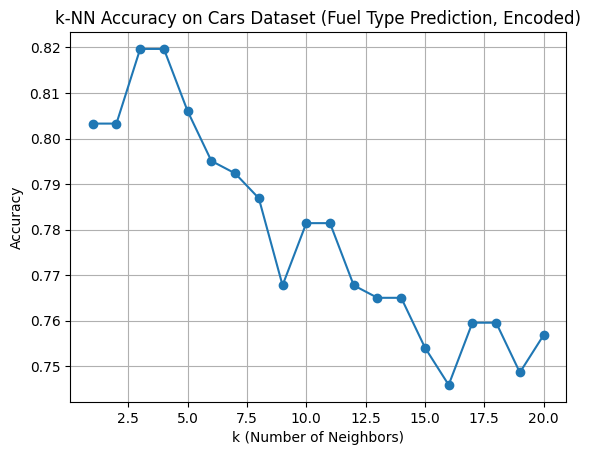

In [23]:
# --- Plot accuracy vs k ---
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy on Cars Dataset (Fuel Type Prediction, Encoded)")
plt.grid(True)
plt.show()